In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [10]:
Arise_Meta = pd.read_csv("Arise_Meta.csv")
Max_QuerGPT = pd.read_csv("Max_QuerGPT.csv")
Raise_GPT = pd.read_csv("Raise_GPT.csv")
Rising_Gemini = pd.read_csv("Rising_Gemini.csv")
Top_Gemini = pd.read_csv("Top_Gemini.csv")
Up_Meta = pd.read_csv("Up_Meta.csv")
Worldwide_Generative= pd.read_csv("Worldwide_Generative.csv")

In [11]:
df = pd.concat([Arise_Meta, Max_QuerGPT, Raise_GPT, Rising_Gemini, Top_Gemini, Up_Meta, Worldwide_Generative])

In [12]:
df['Time'] = pd.to_datetime(df['Time'])

In [13]:
df = df.sort_values('Time')

In [14]:
df = df.drop_duplicates()

In [15]:
df.reset_index(drop=True, inplace=True)

In [16]:
print(df.head())
print(df.shape)

  query  search interest increase percent       Time  ChatGPT  Gemini  Meta
0   NaN              NaN              NaN 2021-03-01      0.0     0.0  19.0
1   NaN              NaN              NaN 2021-04-01      0.0     0.0  19.0
2   NaN              NaN              NaN 2021-05-01      0.0     0.0  20.0
3   NaN              NaN              NaN 2021-06-01      0.0     0.0  23.0
4   NaN              NaN              NaN 2021-07-01      0.0     0.0  25.0
(255, 7)


In [17]:
df.to_csv("final_ai_dataset.csv", index=False)

In [18]:
print(df.head())
print(df.info())
print(df.describe())

  query  search interest increase percent       Time  ChatGPT  Gemini  Meta
0   NaN              NaN              NaN 2021-03-01      0.0     0.0  19.0
1   NaN              NaN              NaN 2021-04-01      0.0     0.0  19.0
2   NaN              NaN              NaN 2021-05-01      0.0     0.0  20.0
3   NaN              NaN              NaN 2021-06-01      0.0     0.0  23.0
4   NaN              NaN              NaN 2021-07-01      0.0     0.0  25.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   query             194 non-null    object        
 1   search interest   194 non-null    float64       
 2   increase percent  194 non-null    object        
 3   Time              61 non-null     datetime64[ns]
 4   ChatGPT           61 non-null     float64       
 5   Gemini            61 non-null     float64       
 6   Met

In [19]:
df.isnull().sum()

query                61
search interest      61
increase percent     61
Time                194
ChatGPT             194
Gemini              194
Meta                194
dtype: int64

In [20]:
# See total rows and % missing
print(df.shape)
print(df.isnull().mean() * 100)

(255, 7)
query               23.921569
search interest     23.921569
increase percent    23.921569
Time                76.078431
ChatGPT             76.078431
Gemini              76.078431
Meta                76.078431
dtype: float64


In [21]:
df['ChatGPT'] = df['ChatGPT'].fillna(method='ffill')
df['Gemini']  = df['Gemini'].fillna(method='ffill')
df['Meta']    = df['Meta'].fillna(method='ffill')
df['Time']    = df['Time'].fillna(method='ffill')

C:\Users\HP\AppData\Local\Temp\ipykernel_6920\130520711.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ChatGPT'] = df['ChatGPT'].fillna(method='ffill')
C:\Users\HP\AppData\Local\Temp\ipykernel_6920\130520711.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Gemini']  = df['Gemini'].fillna(method='ffill')
C:\Users\HP\AppData\Local\Temp\ipykernel_6920\130520711.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Meta']    = df['Meta'].fillna(method='ffill')
C:\Users\HP\AppData\Local\Temp\ipykernel_6920\130520711.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Time']    = df['Time'].fillna(method='ffill')


In [22]:
df_clean = df.dropna(subset=['Time'])

In [23]:
df_clean.isnull().sum()

query               61
search interest     61
increase percent    61
Time                 0
ChatGPT              0
Gemini               0
Meta                 0
dtype: int64

In [24]:
# Check exact column names
print(df_clean.columns.tolist())

['query', 'search interest', 'increase percent', 'Time', 'ChatGPT', 'Gemini', 'Meta']


In [25]:
df_clean = df_clean.dropna(subset=['query', 'search interest', 'increase percent'])  # adjust name here

In [26]:
df_clean.isnull().sum()

query               0
search interest     0
increase percent    0
Time                0
ChatGPT             0
Gemini              0
Meta                0
dtype: int64

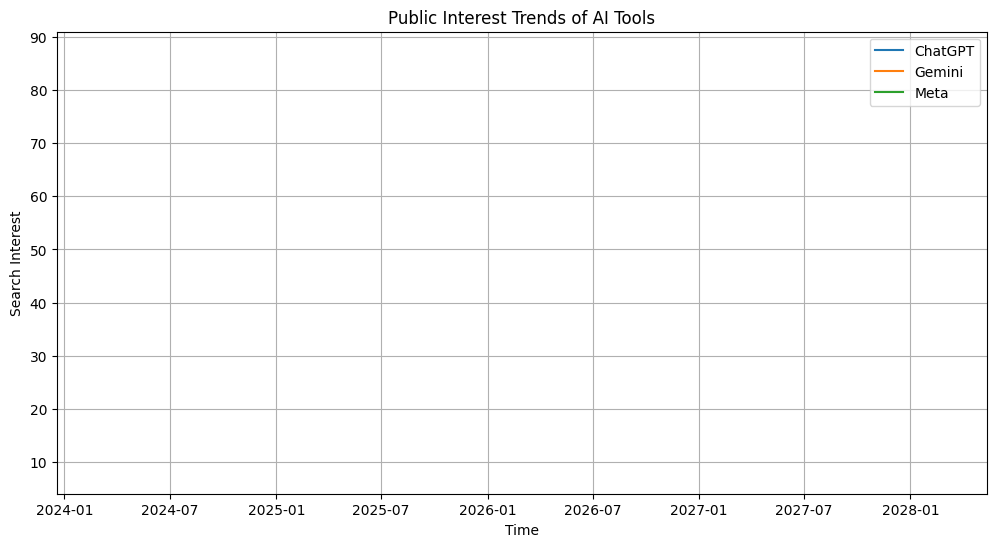

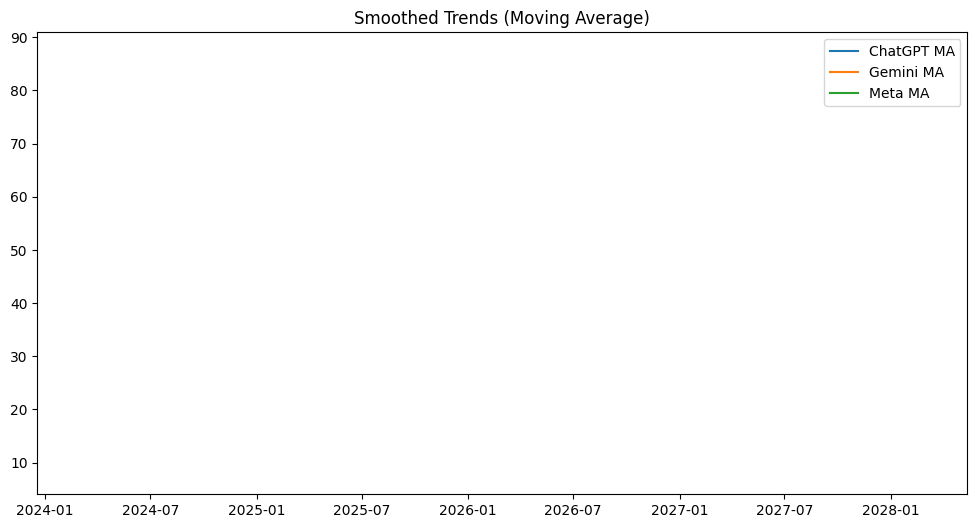

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df_clean['Time'], df_clean['ChatGPT'], label='ChatGPT')
plt.plot(df_clean['Time'], df_clean['Gemini'], label='Gemini')
plt.plot(df_clean['Time'], df_clean['Meta'], label='Meta')

plt.xlabel("Time")
plt.ylabel("Search Interest")
plt.title("Public Interest Trends of AI Tools")

plt.legend()
plt.grid()

plt.show()
df_clean['ChatGPT_MA'] = df_clean['ChatGPT'].rolling(window=3).mean()
df_clean['Gemini_MA'] = df_clean['Gemini'].rolling(window=3).mean()
df_clean['Meta_MA'] = df_clean['Meta'].rolling(window=3).mean()

plt.figure(figsize=(12,6))

plt.plot(df_clean['Time'], df_clean['ChatGPT_MA'], label='ChatGPT MA')
plt.plot(df_clean['Time'], df_clean['Gemini_MA'], label='Gemini MA')
plt.plot(df_clean['Time'], df_clean['Meta_MA'], label='Meta MA')

plt.title("Smoothed Trends (Moving Average)")
plt.legend()
plt.show()

In [28]:
print(df_clean.dtypes)
print(df_clean[['Time', 'ChatGPT', 'Gemini', 'Meta']].head(10))

query                       object
search interest            float64
increase percent            object
Time                datetime64[ns]
ChatGPT                    float64
Gemini                     float64
Meta                       float64
ChatGPT_MA                 float64
Gemini_MA                  float64
Meta_MA                    float64
dtype: object
         Time  ChatGPT  Gemini  Meta
61 2026-03-01     87.0    32.0   8.0
62 2026-03-01     87.0    32.0   8.0
63 2026-03-01     87.0    32.0   8.0
64 2026-03-01     87.0    32.0   8.0
65 2026-03-01     87.0    32.0   8.0
66 2026-03-01     87.0    32.0   8.0
67 2026-03-01     87.0    32.0   8.0
68 2026-03-01     87.0    32.0   8.0
69 2026-03-01     87.0    32.0   8.0
70 2026-03-01     87.0    32.0   8.0


In [29]:
# Convert Time to datetime
df_clean['Time'] = pd.to_datetime(df_clean['Time'])

# Convert values to numeric (forces errors to NaN)
df_clean['ChatGPT'] = pd.to_numeric(df_clean['ChatGPT'], errors='coerce')
df_clean['Gemini']  = pd.to_numeric(df_clean['Gemini'], errors='coerce')
df_clean['Meta']    = pd.to_numeric(df_clean['Meta'], errors='coerce')

print(df_clean.dtypes)  # Verify

query                       object
search interest            float64
increase percent            object
Time                datetime64[ns]
ChatGPT                    float64
Gemini                     float64
Meta                       float64
ChatGPT_MA                 float64
Gemini_MA                  float64
Meta_MA                    float64
dtype: object


In [30]:
# Check how many unique dates exist
print(df_clean['Time'].nunique())
print(df_clean['Time'].value_counts().head(10))

# Remove duplicate rows
df_clean = df_clean.drop_duplicates(subset=['Time'])

print(df_clean.shape)  # Should have far fewer rows now
print(df_clean.head())

1
Time
2026-03-01    194
Name: count, dtype: int64
(1, 10)
             query  search interest increase percent       Time  ChatGPT  \
61  fb ads library              0.0              80% 2026-03-01     87.0   

    Gemini  Meta  ChatGPT_MA  Gemini_MA  Meta_MA  
61    32.0   8.0         NaN        NaN      NaN  


In [31]:
print(df_clean['query'].unique())
print(df_clean['query'].nunique())
print(df_clean[['query', 'search interest', 'increase percent', 'ChatGPT', 'Gemini', 'Meta']].head(20))

['fb ads library']
1
             query  search interest increase percent  ChatGPT  Gemini  Meta
61  fb ads library              0.0              80%     87.0    32.0   8.0


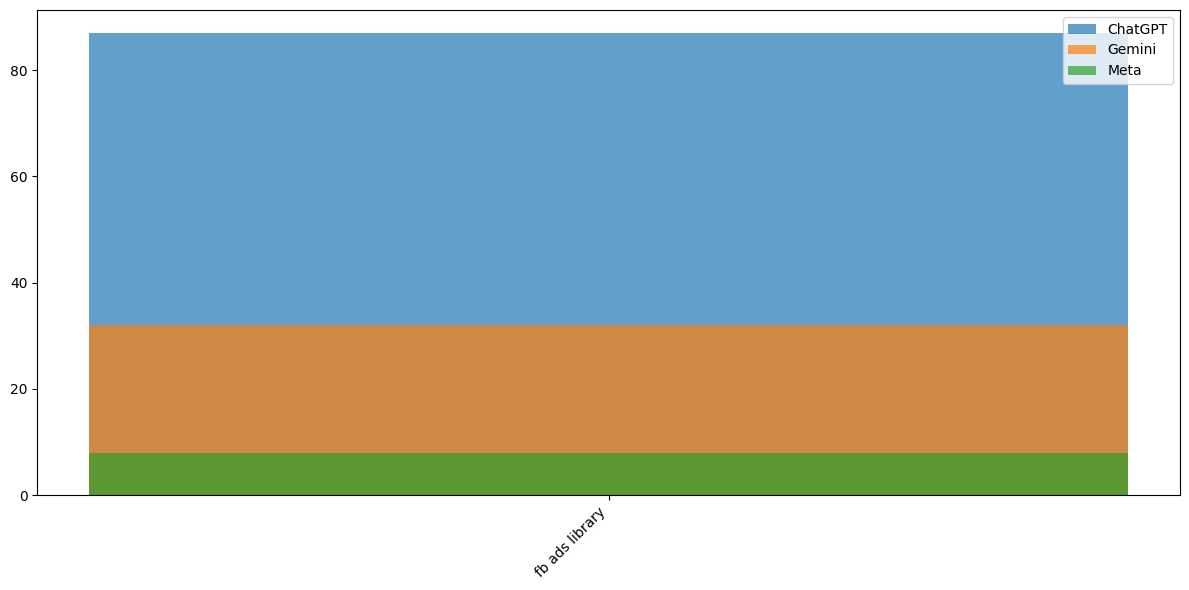

In [32]:
plt.figure(figsize=(12, 6))
df_plot = df_clean[['query', 'ChatGPT', 'Gemini', 'Meta']].drop_duplicates()
x = range(len(df_plot))
plt.bar(x, df_plot['ChatGPT'], label='ChatGPT', alpha=0.7)
plt.bar(x, df_plot['Gemini'], label='Gemini', alpha=0.7)
plt.bar(x, df_plot['Meta'], label='Meta', alpha=0.7)
plt.xticks(x, df_plot['query'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# Load the original file again and inspect it properly
print(df.shape)
print(df.head(20))
print(df['query'].value_counts())

(255, 7)
   query  search interest increase percent       Time  ChatGPT  Gemini  Meta
0    NaN              NaN              NaN 2021-03-01      0.0     0.0  19.0
1    NaN              NaN              NaN 2021-04-01      0.0     0.0  19.0
2    NaN              NaN              NaN 2021-05-01      0.0     0.0  20.0
3    NaN              NaN              NaN 2021-06-01      0.0     0.0  23.0
4    NaN              NaN              NaN 2021-07-01      0.0     0.0  25.0
5    NaN              NaN              NaN 2021-08-01      0.0     0.0  26.0
6    NaN              NaN              NaN 2021-09-01      0.0     0.0  47.0
7    NaN              NaN              NaN 2021-10-01      0.0     0.0  56.0
8    NaN              NaN              NaN 2021-11-01      0.0     0.0  68.0
9    NaN              NaN              NaN 2021-12-01      0.0     0.0  61.0
10   NaN              NaN              NaN 2022-01-01      0.0     0.0  61.0
11   NaN              NaN              NaN 2022-02-01      0.0     

In [34]:
# Time series data (ChatGPT, Gemini, Meta trends over time)
df_trends = df[df['Time'].notna()][['Time', 'ChatGPT', 'Gemini', 'Meta']].drop_duplicates().sort_values('Time')

# Query/search interest data
df_queries = df[df['query'].notna()][['query', 'search interest', 'increase percent']].drop_duplicates()

print(df_trends.shape)
print(df_trends.head())
print("---")
print(df_queries.shape)
print(df_queries.head())

(61, 4)
        Time  ChatGPT  Gemini  Meta
0 2021-03-01      0.0     0.0  19.0
1 2021-04-01      0.0     0.0  19.0
2 2021-05-01      0.0     0.0  20.0
3 2021-06-01      0.0     0.0  23.0
4 2021-07-01      0.0     0.0  25.0
---
(194, 3)
             query  search interest increase percent
61  fb ads library              0.0              80%
62    ads.facebook              0.0              80%
63  facebook войти              0.0              40%
64  facebook stock              0.0              30%
65        fb stock              0.0              30%


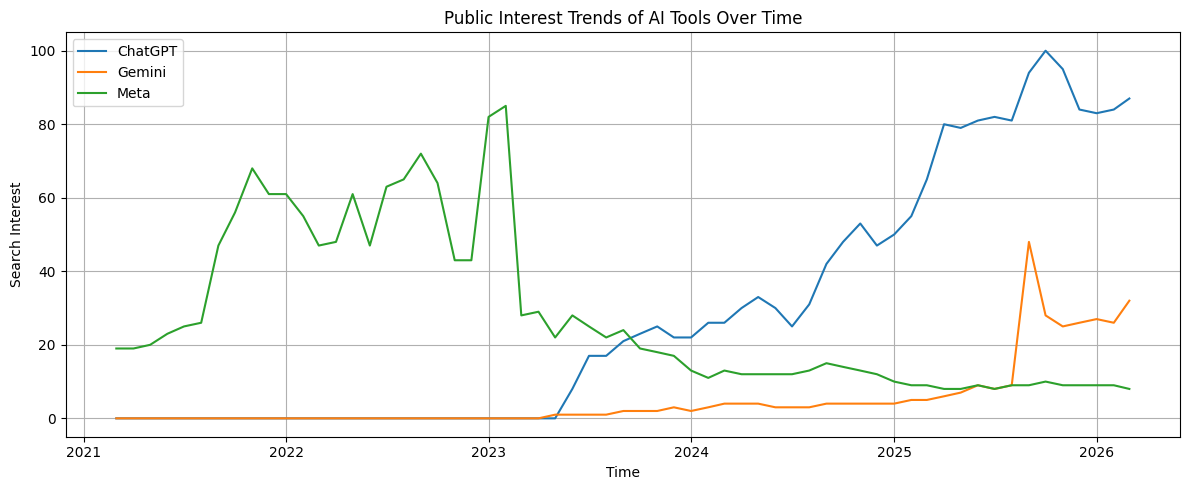

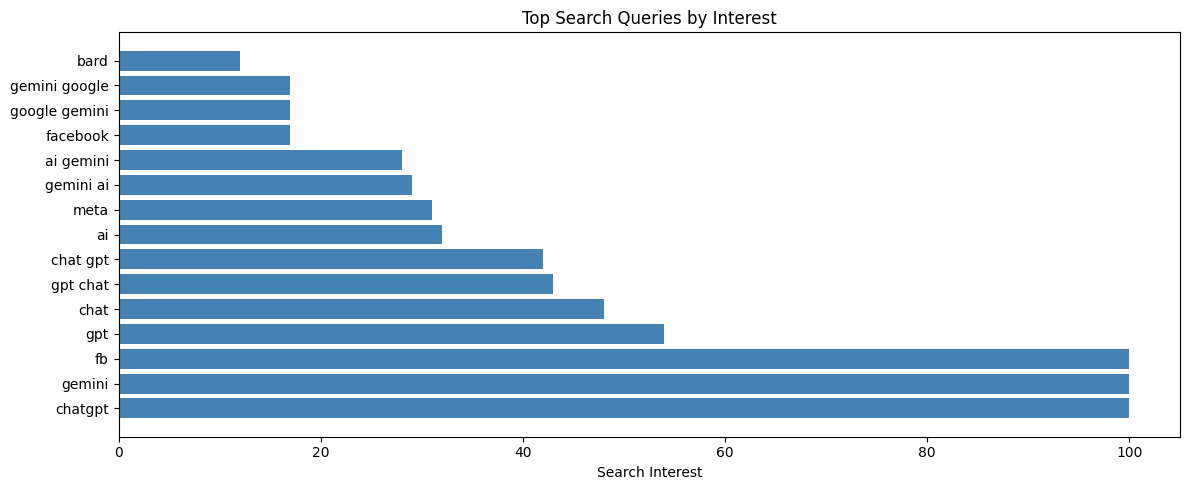

In [35]:
# Plot 1 — Trends over time
plt.figure(figsize=(12, 5))
plt.plot(df_trends['Time'], df_trends['ChatGPT'], label='ChatGPT')
plt.plot(df_trends['Time'], df_trends['Gemini'], label='Gemini')
plt.plot(df_trends['Time'], df_trends['Meta'], label='Meta')
plt.title('Public Interest Trends of AI Tools Over Time')
plt.xlabel('Time')
plt.ylabel('Search Interest')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2 — Top queries bar chart
plt.figure(figsize=(12, 5))
df_queries_sorted = df_queries.sort_values('search interest', ascending=False).head(15)
plt.barh(df_queries_sorted['query'], df_queries_sorted['search interest'], color='steelblue')
plt.title('Top Search Queries by Interest')
plt.xlabel('Search Interest')
plt.tight_layout()
plt.show()

Average Popularity:
ChatGPT    28.622951
Gemini      5.245902
Meta       28.147541
dtype: float64


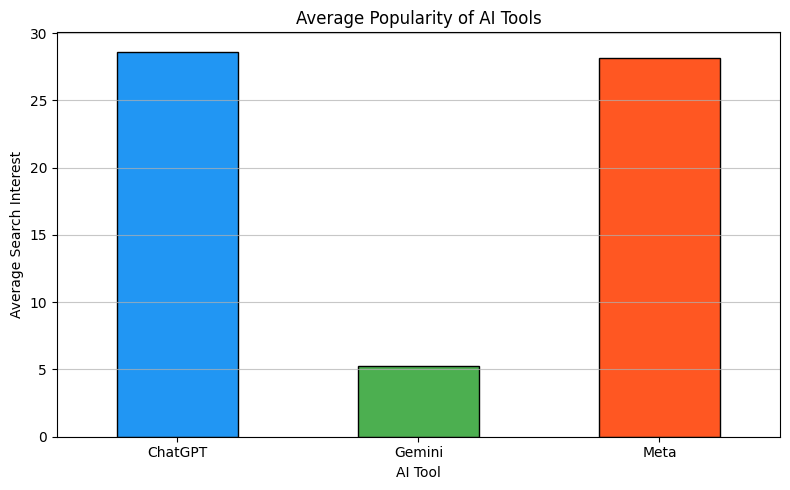

In [36]:
# Average Popularity
avg_popularity = df_trends[['ChatGPT', 'Gemini', 'Meta']].mean()
print("Average Popularity:")
print(avg_popularity)

# Plot
plt.figure(figsize=(8, 5))
avg_popularity.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF5722'], edgecolor='black')
plt.title('Average Popularity of AI Tools')
plt.xlabel('AI Tool')
plt.ylabel('Average Search Interest')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

Peak Search Interest:
ChatGPT    100.0
Gemini      48.0
Meta        85.0
dtype: float64

Peak Dates (row index):
ChatGPT: 100.0 on 2025-10-01 00:00:00
Gemini: 48.0 on 2025-09-01 00:00:00
Meta: 85.0 on 2023-02-01 00:00:00


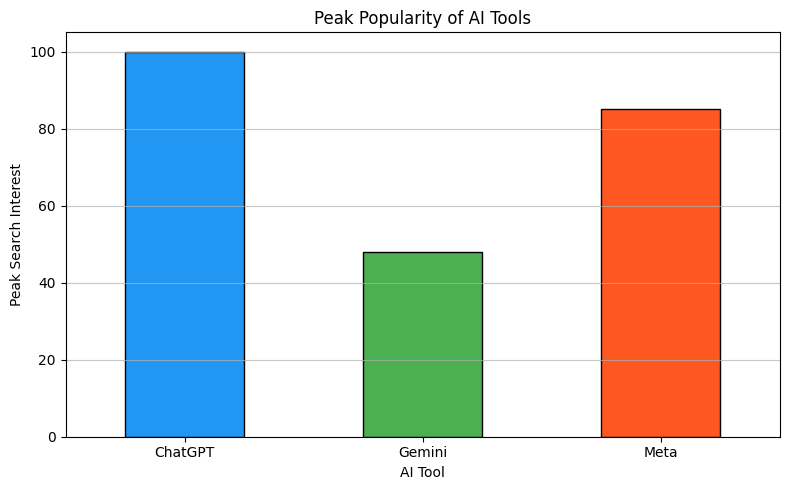

In [37]:
# Peak Popularity
peak = df_trends[['ChatGPT', 'Gemini', 'Meta']].max()
peak_dates = df_trends[['ChatGPT', 'Gemini', 'Meta']].idxmax()

print("Peak Search Interest:")
print(peak)
print("\nPeak Dates (row index):")
for col in ['ChatGPT', 'Gemini', 'Meta']:
    idx = peak_dates[col]
    date = df_trends.loc[idx, 'Time']
    print(f"{col}: {peak[col]} on {date}")

# Plot
plt.figure(figsize=(8, 5))
peak.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF5722'], edgecolor='black')
plt.title('Peak Popularity of AI Tools')
plt.xlabel('AI Tool')
plt.ylabel('Peak Search Interest')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

In [38]:
peak = df_trends[['ChatGPT', 'Gemini', 'Meta']].max()
peak_dates = {}
for col in ['ChatGPT', 'Gemini', 'Meta']:
    idx = df_trends[col].idxmax()
    peak_dates[col] = df_trends.loc[idx, 'Time']

print("Maximum Popularity:")
for col in ['ChatGPT', 'Gemini', 'Meta']:
    print(f"{col}: {peak[col]} on {peak_dates[col]}")

Maximum Popularity:
ChatGPT: 100.0 on 2025-10-01 00:00:00
Gemini: 48.0 on 2025-09-01 00:00:00
Meta: 85.0 on 2023-02-01 00:00:00



Overall Growth (First to Last):
ChatGPT: inf%
Gemini: inf%
Meta: -57.89%


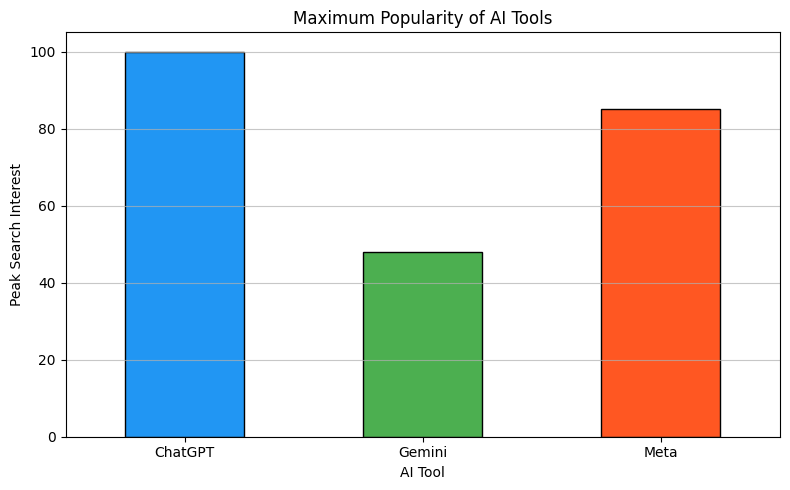

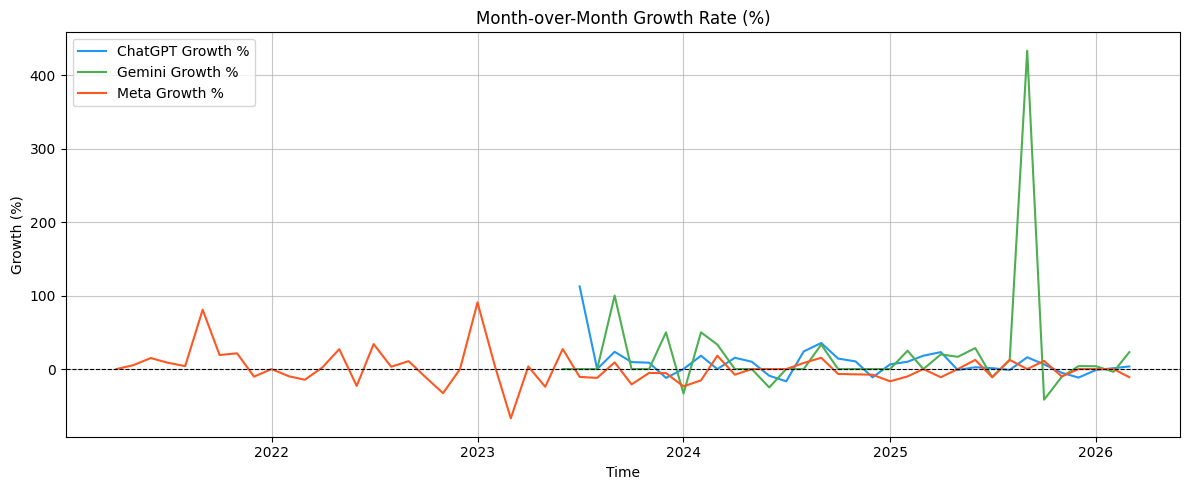

In [39]:
df_trends_sorted = df_trends.sort_values('Time').copy()
for col in ['ChatGPT', 'Gemini', 'Meta']:
    df_trends_sorted[f'{col}_growth'] = df_trends_sorted[col].pct_change() * 100

print("\nOverall Growth (First to Last):")
for col in ['ChatGPT', 'Gemini', 'Meta']:
    first = df_trends_sorted[col].iloc[0]
    last  = df_trends_sorted[col].iloc[-1]
    growth = ((last - first) / first) * 100 if first != 0 else float('inf')
    print(f"{col}: {growth:.2f}%")


plt.figure(figsize=(8, 5))
peak.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF5722'], edgecolor='black')
plt.title('Maximum Popularity of AI Tools')
plt.xlabel('AI Tool')
plt.ylabel('Peak Search Interest')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))
for col, color in zip(['ChatGPT', 'Gemini', 'Meta'], ['#2196F3', '#4CAF50', '#FF5722']):
    plt.plot(df_trends_sorted['Time'], df_trends_sorted[f'{col}_growth'], label=f'{col} Growth %', color=color)
plt.title('Month-over-Month Growth Rate (%)')
plt.xlabel('Time')
plt.ylabel('Growth (%)')
plt.legend()
plt.grid(True, alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

In [65]:
import pandas as pd

# Step 1: Convert Time and set index
df_clean['Time'] = pd.to_datetime(df_clean['Time'])
df_clean.set_index('Time', inplace=True)

# Step 2: Create Lag Features
df_clean['lag1'] = df_clean['ChatGPT'].shift(1)
df_clean['lag2'] = df_clean['ChatGPT'].shift(2)

# Step 3: Moving Average
df_clean['MA_2'] = df_clean['ChatGPT'].rolling(window=2).mean()

# Step 4: Growth Rate
df_clean['growth'] = df_clean['ChatGPT'].pct_change()

# Step 5: Time Features
df_clean['month'] = df_clean.index.month
df_clean['week'] = df_clean.index.isocalendar().week

# 🔥 Step 6: Handle Missing Values (IMPORTANT)

# Forward fill (use previous value)
df_clean = df_clean.fillna(method='ffill')

# Backward fill (for starting rows)
df_clean = df_clean.fillna(method='bfill')

# Step 7: Final Check
print(df_clean.isnull().sum())  # should be all zeros
print(df_clean.shape)

df_clean.head()

KeyError: 'Time'

In [66]:
print(df_clean.columns)

Index(['query', 'search interest', 'increase percent', 'ChatGPT', 'Gemini',
       'Meta', 'ChatGPT_MA', 'Gemini_MA', 'Meta_MA', 'ChatGPT_lag1',
       'Gemini_lag1', 'Meta_lag1', 'ChatGPT_lag7', 'Gemini_lag7', 'Meta_lag7',
       'ChatGPT_std', 'Gemini_std', 'Meta_std', 'ChatGPT_growth',
       'Gemini_growth', 'Meta_growth', 'year', 'month', 'day', 'week'],
      dtype='object')


In [67]:
import pandas as pd

# Step 1: Ensure index is datetime
df_clean.index = pd.to_datetime(df_clean.index)

# Step 2: Create Lag Features
df_clean['lag1'] = df_clean['ChatGPT'].shift(1)
df_clean['lag2'] = df_clean['ChatGPT'].shift(2)

# Step 3: Moving Average
df_clean['MA_2'] = df_clean['ChatGPT'].rolling(window=2).mean()

# Step 4: Growth Rate
df_clean['growth'] = df_clean['ChatGPT'].pct_change()

# Step 5: Time Features (from index)
df_clean['month'] = df_clean.index.month
df_clean['week'] = df_clean.index.isocalendar().week.astype(int)

# Step 6: Handle Missing Values
df_clean = df_clean.ffill().bfill()

# Step 7: Check
print(df_clean.isnull().sum())
print(df_clean.shape)

df_clean.head()

query               0
search interest     0
increase percent    0
ChatGPT             0
Gemini              0
Meta                0
ChatGPT_MA          0
Gemini_MA           0
Meta_MA             0
ChatGPT_lag1        0
Gemini_lag1         0
Meta_lag1           0
ChatGPT_lag7        0
Gemini_lag7         0
Meta_lag7           0
ChatGPT_std         0
Gemini_std          0
Meta_std            0
ChatGPT_growth      0
Gemini_growth       0
Meta_growth         0
year                0
month               0
day                 0
week                0
lag1                0
lag2                0
MA_2                0
growth              0
dtype: int64
(0, 29)


,query,search interest,increase percent,ChatGPT,Gemini,Meta,ChatGPT_MA,Gemini_MA,Meta_MA,ChatGPT_lag1,...,Gemini_growth,Meta_growth,year,month,day,week,lag1,lag2,MA_2,growth
Time,,,,,,,,,,,,,,,,,,,,,


In [68]:
df_clean = df.copy()   # or reload CSV

In [69]:
import pandas as pd

# Convert Time
df_clean['Time'] = pd.to_datetime(df_clean['Time'])
df_clean.set_index('Time', inplace=True)

# SMALL features only
df_clean['lag1'] = df_clean['ChatGPT'].shift(1)
df_clean['lag2'] = df_clean['ChatGPT'].shift(2)

df_clean['MA_2'] = df_clean['ChatGPT'].rolling(2).mean()
df_clean['growth'] = df_clean['ChatGPT'].pct_change()

# Time features
df_clean['month'] = df_clean.index.month

# Fill missing values
df_clean = df_clean.ffill().bfill()

print(df_clean.shape)

(255, 11)


In [71]:
df_clean = df_clean.drop(columns=['lag1', 'lag2', 'MA_2', 'growth'], errors='ignore')

In [72]:
print(df_clean.shape)
print(df_clean.isnull().sum())
df_clean.head()

(255, 19)
query               0
search interest     0
increase percent    0
ChatGPT             0
Gemini              0
Meta                0
month               0
ChatGPT_lag1        0
ChatGPT_lag2        0
ChatGPT_MA          0
ChatGPT_growth      0
Gemini_lag1         0
Gemini_lag2         0
Gemini_MA           0
Gemini_growth       0
Meta_lag1           0
Meta_lag2           0
Meta_MA             0
Meta_growth         0
dtype: int64


,query,search interest,increase percent,ChatGPT,Gemini,Meta,month,ChatGPT_lag1,ChatGPT_lag2,ChatGPT_MA,ChatGPT_growth,Gemini_lag1,Gemini_lag2,Gemini_MA,Gemini_growth,Meta_lag1,Meta_lag2,Meta_MA,Meta_growth
Time,,,,,,,,,,,,,,,,,,,
2021-03-01,fb ads library,0.0,80%,0.0,0.0,19.0,3,0.0,0.0,0.0,inf,0.0,0.0,0.0,inf,19.0,19.0,19.0,0.000000
2021-04-01,fb ads library,0.0,80%,0.0,0.0,19.0,4,0.0,0.0,0.0,inf,0.0,0.0,0.0,inf,19.0,19.0,19.0,0.000000
2021-05-01,fb ads library,0.0,80%,0.0,0.0,20.0,5,0.0,0.0,0.0,inf,0.0,0.0,0.0,inf,19.0,19.0,19.5,0.052632
2021-06-01,fb ads library,0.0,80%,0.0,0.0,23.0,6,0.0,0.0,0.0,inf,0.0,0.0,0.0,inf,20.0,19.0,21.5,0.150000
2021-07-01,fb ads library,0.0,80%,0.0,0.0,25.0,7,0.0,0.0,0.0,inf,0.0,0.0,0.0,inf,23.0,20.0,24.0,0.086957


In [74]:
import numpy as np

# Replace inf/-inf with NaN, then fill NaN with column median
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# Find which columns have inf values
inf_cols = X.columns[np.isinf(X).any()]
print("Columns with inf:", inf_cols.tolist())

# Find which columns have NaN
nan_cols = X.columns[X.isna().any()]
print("Columns with NaN:", nan_cols.tolist())

Columns with inf: []
Columns with NaN: []


In [75]:
# Check for values too large for float32
import numpy as np

float32_max = np.finfo(np.float32).max  # ~3.4e38
large_cols = X.columns[(X.abs() > float32_max).any()]
print("Columns with float32-overflow values:", large_cols.tolist())

# Also check the actual max values per column
print("\nMax absolute value per column:")
print(X.abs().max().sort_values(ascending=False).head(10))

Columns with float32-overflow values: []

Max absolute value per column:
search interest    100.0
ChatGPT_lag1       100.0
ChatGPT_lag2       100.0
ChatGPT_MA          97.5
Meta                85.0
Meta_lag2           85.0
Meta_lag1           85.0
Meta_MA             83.5
Gemini_lag2         48.0
Gemini_lag1         48.0
dtype: float64


In [76]:
# Check dtypes
print(X.dtypes)

# Check for any object/datetime columns
print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=[np.number]).columns.tolist())

# Also verify shape and a peek at the data
print("\nShape:", X.shape)
print(X.head(2))

search interest    float64
Gemini             float64
Meta               float64
month                int32
ChatGPT_lag1       float64
ChatGPT_lag2       float64
ChatGPT_MA         float64
ChatGPT_growth     float64
Gemini_lag1        float64
Gemini_lag2        float64
Gemini_MA          float64
Gemini_growth      float64
Meta_lag1          float64
Meta_lag2          float64
Meta_MA            float64
Meta_growth        float64
dtype: object

Non-numeric columns:
[]

Shape: (255, 16)
            search interest  Gemini  Meta  month  ChatGPT_lag1  ChatGPT_lag2  \
Time                                                                           
2021-03-01              0.0     0.0  19.0      3           0.0           0.0   
2021-04-01              0.0     0.0  19.0      4           0.0           0.0   

            ChatGPT_MA  ChatGPT_growth  Gemini_lag1  Gemini_lag2  Gemini_MA  \
Time                                                                          
2021-03-01         0.0          

In [77]:
# Reset the datetime index before splitting
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

X = X.reset_index(drop=True).astype(np.float64)
y = y.reset_index(drop=True).astype(np.float64)

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Drop non-numeric columns
X = df_clean.drop(columns=['ChatGPT', 'query', 'increase percent'], errors='ignore')

# Target
y = df_clean['ChatGPT']

# Split (IMPORTANT: no shuffle in time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Check X_train specifically
print(np.isinf(X_train.values).any())
print(np.isnan(X_train.values).any())
print(X_train.values.dtype)

# Nuclear option - check the raw numpy array sum
print(np.isfinite(X_train.values.astype(np.float32)).all())

# Find exact location of problem
mask = ~np.isfinite(X_train.values.astype(np.float32))
rows, cols = np.where(mask)
print("Problem rows:", rows)
print("Problem cols:", cols)
print("Problem col names:", X_train.columns[cols].tolist())

True
False
float64
False
Problem rows: [ 0  0  1  1  2  2  3  3  4  4  5  5  6  6  7  7  8  8  9  9 10 10 11 11
 12 12 13 13 14 14 15 15 16 16 17 17 18 18 19 19 20 20 21 21 22 22 23 23
 24 24 25 25 26 26 27]
Problem cols: [ 7 11  7 11  7 11  7 11  7 11  7 11  7 11  7 11  7 11  7 11  7 11  7 11
  7 11  7 11  7 11  7 11  7 11  7 11  7 11  7 11  7 11  7 11  7 11  7 11
  7 11  7 11  7 11  7]
Problem col names: ['ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_growth', 'ChatGPT_growth', 'Gemini_gro

In [80]:
print(X['ChatGPT_growth'].describe())
print(X['Gemini_growth'].describe())

# See the actual large values
print(X['ChatGPT_growth'].sort_values(ascending=False).head(10))

count    255.000000
mean            inf
std             NaN
min       -0.166667
25%        0.000000
50%        0.000000
75%        0.000000
max             inf
Name: ChatGPT_growth, dtype: float64
count    255.000000
mean            inf
std             NaN
min       -0.416667
25%        0.000000
50%        0.000000
75%        0.000000
max             inf
Name: Gemini_growth, dtype: float64
Time
2021-03-01    inf
2021-04-01    inf
2021-05-01    inf
2021-06-01    inf
2021-07-01    inf
2021-08-01    inf
2021-09-01    inf
2021-10-01    inf
2021-11-01    inf
2021-12-01    inf
Name: ChatGPT_growth, dtype: float64


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [81]:
for col in ['ChatGPT_growth', 'Gemini_growth', 'Meta_growth']:
    X[col] = X[col].clip(-1000, 1000)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error



In [3]:
ai_trends_cleaned_final = pd.read_csv("ai_trends_cleaned_final.csv")

In [4]:
ai_trends_cleaned_final.describe()
ai_trends_cleaned_final.info()
ai_trends_cleaned_final.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time                67 non-null     object 
 1   Year                67 non-null     int64  
 2   Month               67 non-null     int64  
 3   Type                67 non-null     object 
 4   ChatGPT             67 non-null     float64
 5   ChatGPT_lag1        67 non-null     float64
 6   ChatGPT_lag2        67 non-null     float64
 7   ChatGPT_lag3        67 non-null     float64
 8   ChatGPT_MA3         67 non-null     float64
 9   ChatGPT_MA6         67 non-null     float64
 10  ChatGPT_MoM_change  67 non-null     float64
 11  ChatGPT_MoM_pct     67 non-null     float64
 12  Gemini              67 non-null     float64
 13  Gemini_lag1         67 non-null     float64
 14  Gemini_lag2         67 non-null     float64
 15  Gemini_lag3         67 non-null     float64
 16  Gemini_MA3

,Time,Year,Month,Type,ChatGPT,ChatGPT_lag1,ChatGPT_lag2,ChatGPT_lag3,ChatGPT_MA3,ChatGPT_MA6,...,Gemini_MoM_change,Gemini_MoM_pct,Meta,Meta_lag1,Meta_lag2,Meta_lag3,Meta_MA3,Meta_MA6,Meta_MoM_change,Meta_MoM_pct
0,2021-03-01,2021,3,historical,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,19.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
1,2021-04-01,2021,4,historical,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,19.0,19.0,0.0,0.0,0.00,0.0,0.0,0.00
2,2021-05-01,2021,5,historical,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,20.0,19.0,19.0,0.0,0.00,0.0,1.0,5.26
3,2021-06-01,2021,6,historical,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,23.0,20.0,19.0,19.0,19.33,0.0,3.0,15.00
4,2021-07-01,2021,7,historical,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,25.0,23.0,20.0,19.0,20.67,0.0,2.0,8.70


In [5]:
X = ai_trends_cleaned_final[[
    'Gemini',
    'Meta',

    'ChatGPT_lag1',
    'ChatGPT_lag2',
    'ChatGPT_lag3',

    'Gemini_lag1',
    'Gemini_lag2',
    'Gemini_lag3',

    'Meta_lag1',
    'Meta_lag2',
    'Meta_lag3',

    'ChatGPT_MA3',
    'ChatGPT_MA6',

    'Gemini_MA3',
    'Gemini_MA6',

    'Meta_MA3',
    'Meta_MA6',

    'ChatGPT_MoM_change',
    'Gemini_MoM_change',
    'Meta_MoM_change',

    'Month'
]]


Training Shape: (53, 21)
Testing Shape: (14, 21)
 Model Training Completed
Mean Absolute Error (MAE): 9.293214285714285


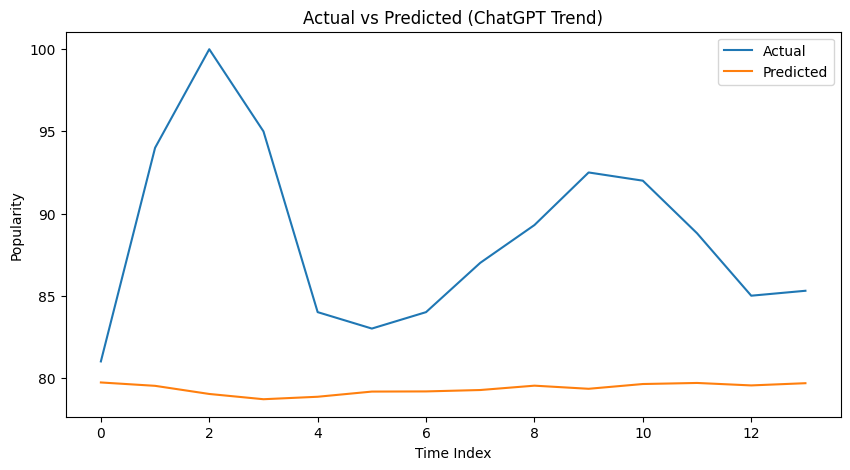

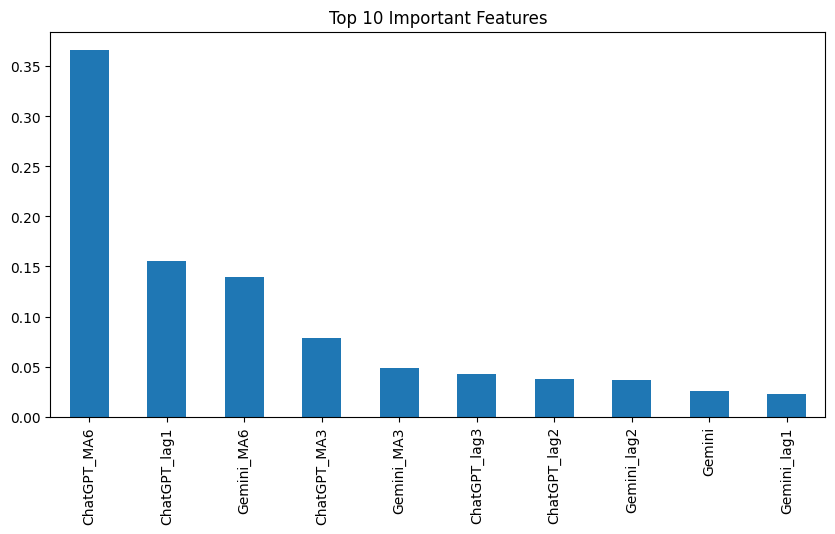

In [8]:
y = ai_trends_cleaned_final['ChatGPT']



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print(" Model Training Completed")

y_pred = model.predict(X_test)



mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)


plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("Actual vs Predicted (ChatGPT Trend)")
plt.xlabel("Time Index")
plt.ylabel("Popularity")

plt.legend()
plt.show()



importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.show()



Training Shape: (53, 21)
Testing Shape: (14, 21)
 Model Training Completed
Mean Absolute Error (MAE): 19.96607142857143


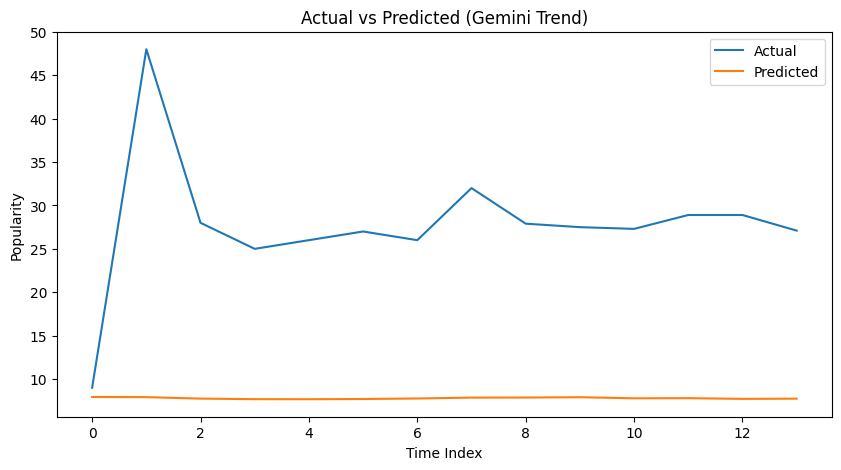

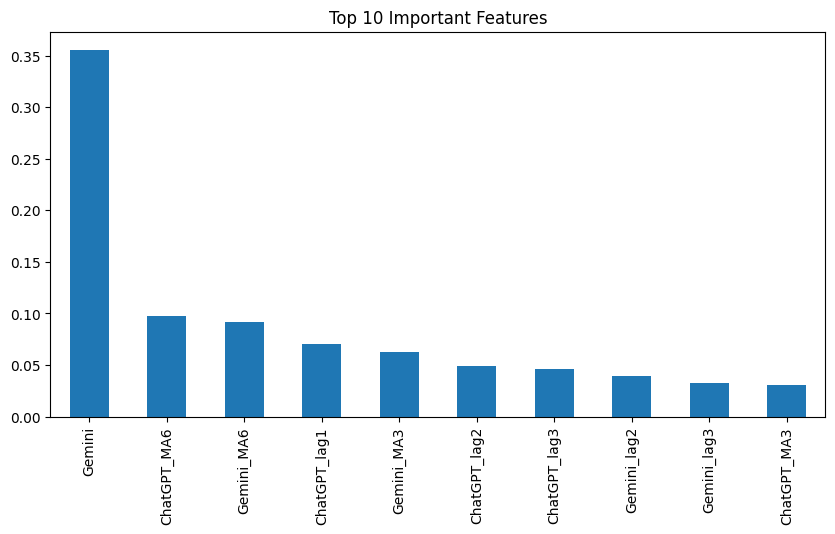

In [10]:
y = ai_trends_cleaned_final['Gemini']



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print(" Model Training Completed")

y_pred = model.predict(X_test)



mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)


plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("Actual vs Predicted (Gemini Trend)")
plt.xlabel("Time Index")
plt.ylabel("Popularity")

plt.legend()
plt.show()



importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.show()



In [14]:
# =========================
# Correct Feature Selection
# =========================

X = ai_trends_cleaned_final[[
    'ChatGPT',
    'Meta',

    'ChatGPT_lag1',
    'ChatGPT_lag2',
    'ChatGPT_lag3',

    'Gemini_lag1',
    'Gemini_lag2',
    'Gemini_lag3',

    'Meta_lag1',
    'Meta_lag2',
    'Meta_lag3',

    'ChatGPT_MA3',
    'ChatGPT_MA6',

    'Gemini_MA3',
    'Gemini_MA6',

    'Meta_MA3',
    'Meta_MA6',

    'ChatGPT_MoM_change',
    'Gemini_MoM_change',
    'Meta_MoM_change',

    'Month'
]]

# Target
y = ai_trends_cleaned_final['Gemini']

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# Train improved model
from sklearn.ensemble import RandomForestRegressor

model_gemini = RandomForestRegressor(
    n_estimators=500,   # increased trees
    max_depth=10,
    random_state=42
)

model_gemini.fit(X_train, y_train)

# Predict
y_pred_gemini = model_gemini.predict(X_test)

# Evaluate
from sklearn.metrics import mean_absolute_error

mae_gemini = mean_absolute_error(
    y_test,
    y_pred_gemini
)

print("Improved Gemini MAE:", mae_gemini)




Improved Gemini MAE: 20.007285714285718


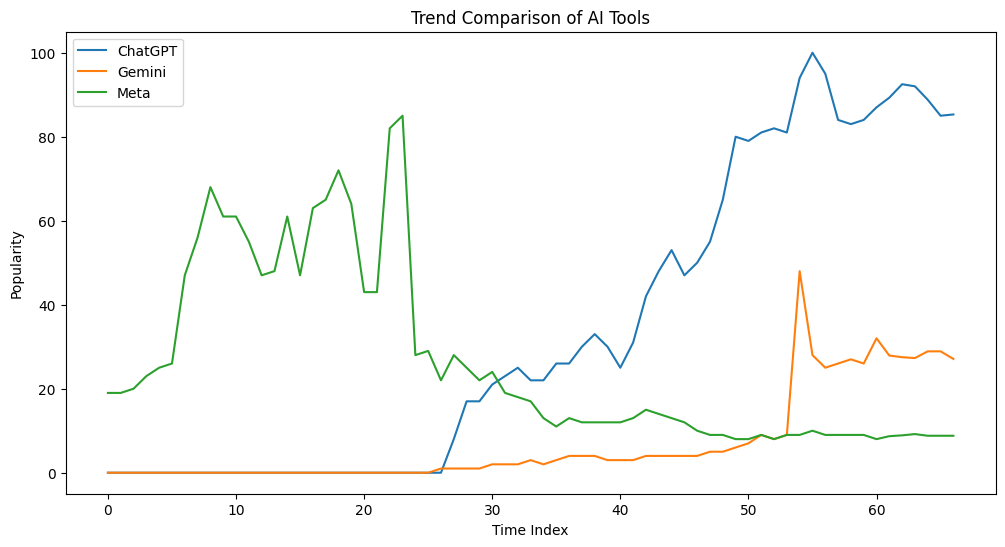

In [15]:
plt.figure(figsize=(12,6))

plt.plot(ai_trends_cleaned_final['ChatGPT'], label='ChatGPT')
plt.plot(ai_trends_cleaned_final['Gemini'], label='Gemini')
plt.plot(ai_trends_cleaned_final['Meta'], label='Meta')

plt.title("Trend Comparison of AI Tools")

plt.xlabel("Time Index")
plt.ylabel("Popularity")

plt.legend()
plt.show()

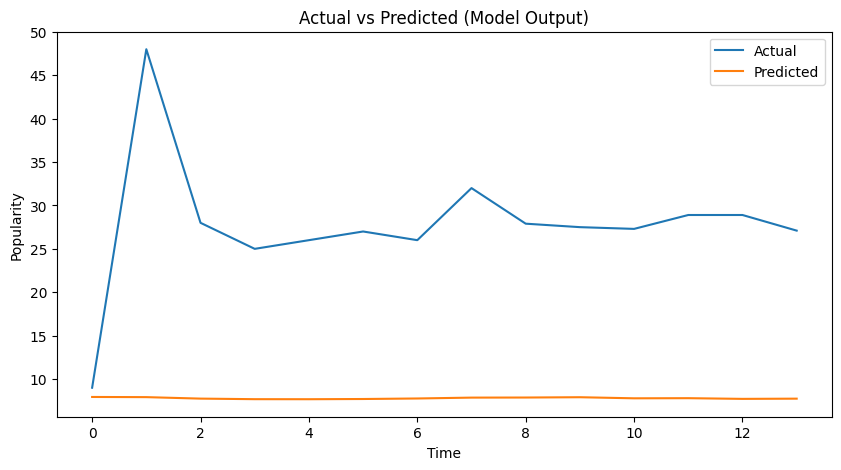

In [16]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("Actual vs Predicted (Model Output)")

plt.xlabel("Time")
plt.ylabel("Popularity")

plt.legend()
plt.show()

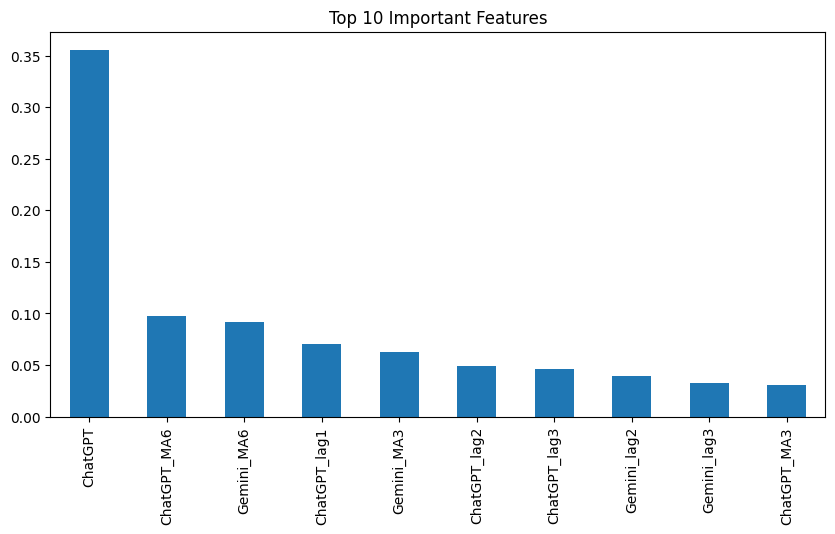

In [17]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.show()

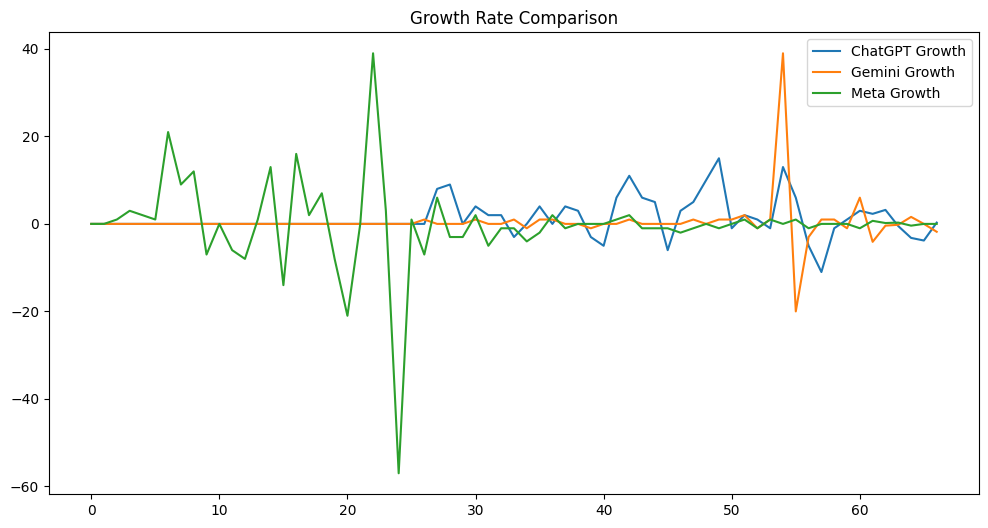

In [19]:
plt.figure(figsize=(12,6))

plt.plot(ai_trends_cleaned_final['ChatGPT_MoM_change'], label='ChatGPT Growth')
plt.plot(ai_trends_cleaned_final['Gemini_MoM_change'], label='Gemini Growth')
plt.plot(ai_trends_cleaned_final['Meta_MoM_change'], label='Meta Growth')

plt.title("Growth Rate Comparison")

plt.legend()
plt.show()

2026-04-08 19:54:22.219 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 19:54:22.653 
  command:

    streamlit run C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-08 19:54:22.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 19:54:22.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 19:54:22.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 19:54:22.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 19:54:22.653 Thread 'MainThread': missing ScriptRunContext! This warn

DeltaGenerator()

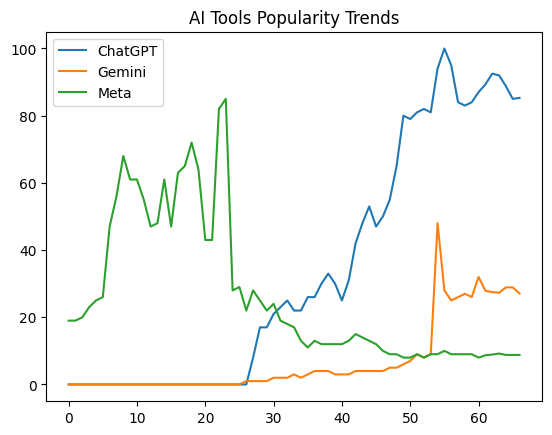

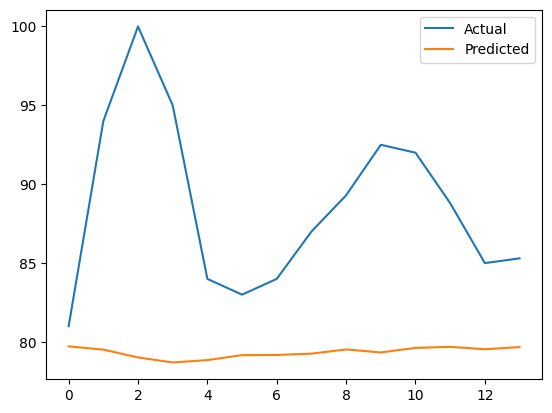

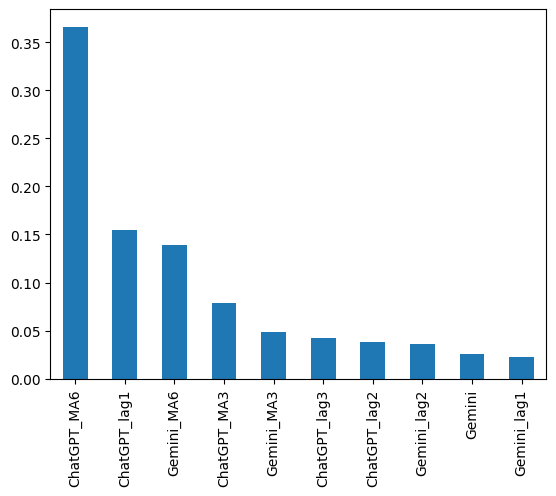

In [23]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error



st.title("AI Tool Trend Analysis Dashboard")

st.write(
"Comparative analysis of ChatGPT, Gemini, and Meta popularity trends."
)



ai_trends_cleaned_final = pd.read_csv("ai_trends_cleaned_final.csv")

# Clean data
ai_trends_cleaned_final.replace([np.inf, -np.inf], np.nan, inplace=True)
ai_trends_cleaned_final = ai_trends_cleaned_final.ffill().bfill()



st.subheader("Dataset Preview")

st.dataframe(ai_trends_cleaned_final.head())


st.subheader("Trend Comparison")

fig, ax = plt.subplots()

ax.plot(ai_trends_cleaned_final['ChatGPT'], label='ChatGPT')
ax.plot(ai_trends_cleaned_final['Gemini'], label='Gemini')
ax.plot(ai_trends_cleaned_final['Meta'], label='Meta')

ax.set_title("AI Tools Popularity Trends")

ax.legend()

st.pyplot(fig)



st.subheader("Train Model")

# Feature Selection

X = ai_trends_cleaned_final[[
    'Gemini',
    'Meta',

    'ChatGPT_lag1',
    'ChatGPT_lag2',
    'ChatGPT_lag3',

    'Gemini_lag1',
    'Gemini_lag2',
    'Gemini_lag3',

    'Meta_lag1',
    'Meta_lag2',
    'Meta_lag3',

    'ChatGPT_MA3',
    'ChatGPT_MA6',

    'Gemini_MA3',
    'Gemini_MA6',

    'Meta_MA3',
    'Meta_MA6',

    'ChatGPT_MoM_change',
    'Gemini_MoM_change',
    'Meta_MoM_change',

    'Month'
]]

y = ai_trends_cleaned_final['ChatGPT']

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# Train Model

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction

y_pred = model.predict(X_test)

# Evaluation

mae = mean_absolute_error(y_test, y_pred)

st.write("Model MAE:", mae)

# =========================
# Prediction Plot
# =========================

st.subheader("Actual vs Predicted")

fig2, ax2 = plt.subplots()

ax2.plot(y_test.values, label="Actual")
ax2.plot(y_pred, label="Predicted")

ax2.legend()

st.pyplot(fig2)

# =========================
# Feature Importance
# =========================

st.subheader("Feature Importance")

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

fig3, ax3 = plt.subplots()

importance.sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    ax=ax3
)

st.pyplot(fig3)

In [1]:
! pip install pytrends



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
from pytrends.request import TrendReq
pytrends = TrendReq()


In [3]:
keywords = ["ChatGPT", "Gemini", "Meta"]
pytrends.build_payload(
    keywords,
    timeframe='today 5-y'
)

data = pytrends.interest_over_time()

# Save file
data.to_csv("ai_trends_realtime.csv")

print("Real-time dataset downloaded")

Real-time dataset downloaded


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


In [4]:
import pandas as pd


df = pd.read_csv("ai_trends_realtime.csv")


print(df.head())


print(df.columns)


print(df.shape)

         date  ChatGPT  Gemini  Meta  isPartial
0  2021-04-18        0       1     1      False
1  2021-04-25        0       1     1      False
2  2021-05-02        0       1     1      False
3  2021-05-09        0       1     1      False
4  2021-05-16        0       2     1      False
Index(['date', 'ChatGPT', 'Gemini', 'Meta', 'isPartial'], dtype='object')
(262, 5)


In [1]:
import pandas as pd


df = pd.read_csv("ai_adoption_full.csv")


print(df.head())


print(df.columns)


print(df.shape)

         Time  ChatGPT  Gemini  Meta  ChatGPT_mentions  Gemini_mentions  \
0  2022-06-01     0.00    0.00  0.00                16               10   
1  2022-07-01     3.16    0.99  0.00                53                0   
2  2022-08-01     1.53    2.93  0.00                 0               27   
3  2022-09-01     0.00    0.00  0.12                19                0   
4  2022-10-01     1.09    0.00  4.93                19                0   

   Meta_mentions  Likes_Count  Comments_Count  Shares_Count  \
0              0            0               0           702   
1             20         1893             334           717   
2              0         1447             386          1164   
3              0          104             223           271   
4             20         2019             458          1319   

   Positive_Sentiment  Negative_Sentiment  Month  Year  lag1  lag2  lag3  \
0              0.7150              0.1513      6  2022  0.00  3.05  1.30   
1              0.7

In [2]:

print(df.isnull().sum())

print(df.dtypes)

print(df.describe())

Time                  0
ChatGPT               0
Gemini                0
Meta                  0
ChatGPT_mentions      0
Gemini_mentions       0
Meta_mentions         0
Likes_Count           0
Comments_Count        0
Shares_Count          0
Positive_Sentiment    0
Negative_Sentiment    0
Month                 0
Year                  0
lag1                  0
lag2                  0
lag3                  0
MA3                   0
MA6                   0
MoM_change            0
dtype: int64
Time                   object
ChatGPT               float64
Gemini                float64
Meta                  float64
ChatGPT_mentions        int64
Gemini_mentions         int64
Meta_mentions           int64
Likes_Count             int64
Comments_Count          int64
Shares_Count            int64
Positive_Sentiment    float64
Negative_Sentiment    float64
Month                   int64
Year                    int64
lag1                  float64
lag2                  float64
lag3                  float

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


df = pd.read_csv("ai_adoption_full.csv")

features = [
    'Gemini',
    'Meta',

    'ChatGPT_mentions',
    'Gemini_mentions',
    'Meta_mentions',

    'Likes_Count',
    'Comments_Count',
    'Shares_Count',

    'Positive_Sentiment',
    'Negative_Sentiment',

    'Month',
    'Year',

    'lag1',
    'lag2',
    'lag3',

    'MA3',
    'MA6',

    'MoM_change'
]


target = 'ChatGPT'

X = df[features]
y = df[target]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4.632045000000102
RMSE: 5.168086244950916
R2 Score: -4.377655481051523


Text(0.5, 1.0, 'Feature Importance')

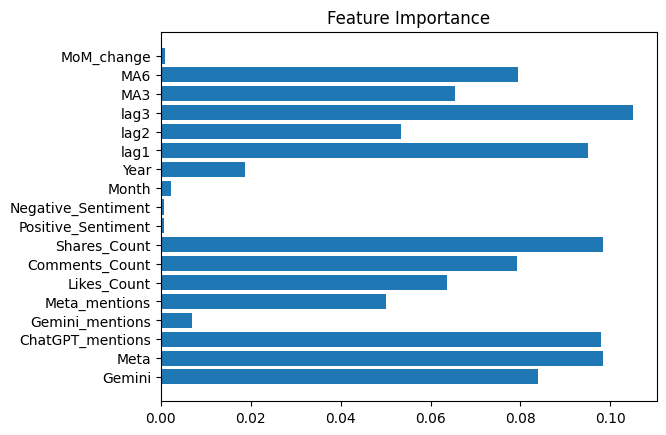

In [4]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure()

plt.barh(features, importance)

plt.title("Feature Importance")


In [5]:
import joblib

joblib.dump(
    model,
    "ai_trend_model.pkl"
)

print("Model Saved")

Model Saved


In [6]:
future_input = X_test.tail(1)

future_pred = model.predict(
    future_input
)

print("Next Month Prediction:", future_pred)

Next Month Prediction: [90.5538]


In [12]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# ===============================
# Step 1 — Load Dataset
# ===============================

df = pd.read_csv("ai_adoption_full.csv")

# ===============================
# Step 2 — Create Naive Prediction
# Next value = Previous value
# ===============================

df["Naive_Prediction"] = df["ChatGPT"].shift(1)

# Remove first row (NaN created)
df = df.dropna()

# ===============================
# Step 3 — Train-Test Split
# (Time-series split)
# ===============================

split_index = int(len(df) * 0.8)

train = df[:split_index]
test = df[split_index:]

y_test = test["ChatGPT"]
y_pred = test["Naive_Prediction"]

# ===============================
# Step 4 — Evaluate Model
# ===============================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Naive Model Performance")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ===============================
# Step 5 — Save Naive Model
# ===============================

# Save last value (used for prediction)
last_value = df["ChatGPT"].iloc[-1]

joblib.dump(
    last_value,
    "naive_model.pkl"
)

print("Naive model saved successfully")

# ===============================
# Step 6 — Future Prediction
# ===============================

future_months = 6

future_predictions = []

for i in range(future_months):
    future_predictions.append(last_value)

print("\nFuture Predictions:")
print(future_predictions)

# ===============================
# Step 7 — Save Future Predictions
# ===============================

future_df = pd.DataFrame({
    "Month": range(1, future_months + 1),
    "Predicted_ChatGPT": future_predictions
})

future_df.to_csv(
    "future_predictions.csv",
    index=False
)

print("Future predictions saved as CSV")

Naive Model Performance
MAE: 2.0450000000000017
RMSE: 2.4249886597673007
R2 Score: -0.18400325045845833
Naive model saved successfully

Future Predictions:
[np.float64(96.3), np.float64(96.3), np.float64(96.3), np.float64(96.3), np.float64(96.3), np.float64(96.3)]
Future predictions saved as CSV


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# =========================
# Load Model
# =========================
model = joblib.load("naive_model.pkl")

# =========================
# Load Dataset
# =========================
df = pd.read_csv("ai_adoption_full.csv")

# =========================
# Get Last Known Value
# =========================
last_value = df["ChatGPT"].iloc[-1]

# =========================
# Generate 12-Week Prediction
# =========================
weeks = np.arange(1, 13)

predictions = []
current_value = last_value

for i in weeks:
    
    # Simple prediction logic
    predicted = current_value + np.random.randint(-2, 5)

    # Prevent negative values
    if predicted < 0:
        predicted = 0

    predictions.append(predicted)
    current_value = predicted

# =========================
# Create DataFrame
# =========================
future_df = pd.DataFrame({
    "Week": weeks,
    "Predicted_Popularity": predictions
})

# =========================
# Print Results
# =========================
print("\n12-Week Popularity Prediction\n")
print(future_df)

# =========================
# Save CSV
# =========================
future_df.to_csv("12_week_prediction.csv", index=False)

print("\nPrediction CSV saved successfully!")

# =========================
# Plot Graph
# =========================
plt.figure(figsize=(10,5))

plt.plot(
    future_df["Week"],
    future_df["Predicted_Popularity"],
    marker='o'
)

plt.title("12-Week AI Popularity Prediction")
plt.xlabel("Week")
plt.ylabel("Popularity Score")

plt.grid(True)

plt.show()


12-Week Popularity Prediction

    Week  Predicted_Popularity
0      1                  95.3
1      2                  95.3
2      3                  96.3
3      4                 100.3
4      5                 101.3
5      6                 100.3
6      7                 101.3
7      8                 103.3
8      9                 101.3
9     10                 101.3
10    11                 101.3
11    12                 100.3

Prediction CSV saved successfully!


C:\Users\HP\AppData\Local\Temp\ipykernel_24044\2565077706.py:79: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [1]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# =========================
# Title
# =========================
st.title("📈 AI Tools 12-Week Popularity Prediction")

# =========================
# Load Model
# =========================
model = joblib.load("naive_model.pkl")

# =========================
# Load Dataset
# =========================
df = pd.read_csv("ai_adoption_full.csv")

# =========================
# Show Dataset
# =========================
st.subheader("Dataset Preview")
st.write(df.head())

# =========================
# Last Known Value
# =========================
last_value = df["ChatGPT"].iloc[-1]

# =========================
# Generate 12 Week Prediction
# =========================
weeks = np.arange(1, 13)

# Simple prediction logic
predictions = []

current_value = last_value

for i in weeks:
    predicted = current_value + np.random.randint(-2, 5)
    
    # Keep values positive
    if predicted < 0:
        predicted = 0
        
    predictions.append(predicted)
    current_value = predicted

# =========================
# Prediction DataFrame
# =========================
future_df = pd.DataFrame({
    "Week": weeks,
    "Predicted Popularity": predictions
})

# =========================
# Display Predictions
# =========================
st.subheader("12-Week Popularity Forecast")
st.write(future_df)

# =========================
# Plot Graph
# =========================
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    future_df["Week"],
    future_df["Predicted Popularity"],
    marker='o'
)

ax.set_title("12-Week AI Popularity Prediction")
ax.set_xlabel("Week")
ax.set_ylabel("Popularity Score")

st.pyplot(fig)

# =========================
# Download CSV
# =========================
csv = future_df.to_csv(index=False)

st.download_button(
    label="Download Prediction CSV",
    data=csv,
    file_name="12_week_prediction.csv",
    mime="text/csv"
)

2026-05-11 16:34:16.473 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 16:34:17.321 
  command:

    streamlit run C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-11 16:34:17.322 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 16:34:17.394 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 16:34:17.395 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 16:34:17.450 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 16:34:17.451 Thread 'MainThread': missing ScriptRunContext! This warn

False

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# Sample Dataset
# -----------------------------

dates = pd.date_range(start='2023-01-01', periods=20, freq='M')

actual = [
    45, 49, 53, 54, 57,
    60, 62, 65, 68, 69,
    72, 73, 75, 77, 79,
    81, 83, 85, 87, 89
]

df = pd.DataFrame({
    'Date': dates,
    'Actual': actual
})

# -----------------------------
# Naive Forecasting
# -----------------------------

df['Predicted'] = df['Actual'].shift(1)

# Remove first NaN row
df = df.dropna()

# -----------------------------
# Evaluation Metrics
# -----------------------------

mae = mean_absolute_error(df['Actual'], df['Predicted'])
rmse = np.sqrt(mean_squared_error(df['Actual'], df['Predicted']))
r2 = r2_score(df['Actual'], df['Predicted'])

# -----------------------------
# Future Prediction (12 Weeks)
# -----------------------------

future_dates = pd.date_range(
    start=df['Date'].iloc[-1],
    periods=13,
    freq='M'
)[1:]

future_values = [df['Actual'].iloc[-1]] * 12

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(14,7))

# Actual values
plt.plot(
    df['Date'],
    df['Actual'],
    marker='o',
    linewidth=2,
    label='Actual Popularity'
)

# Predicted values
plt.plot(
    df['Date'],
    df['Predicted'],
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Predicted Popularity (Naive)'
)

# Future forecast
plt.plot(
    future_dates,
    future_values,
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Future Forecast'
)

# Forecast region
plt.axvspan(
    future_dates[0],
    future_dates[-1],
    alpha=0.2
)

# Title and labels
plt.title(
    'Actual vs Predicted Popularity (Naive Forecasting) – ChatGPT',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Date', fontsize=14)
plt.ylabel('Popularity Score', fontsize=14)

# Grid
plt.grid(True)

# Legend
plt.legend()

# Metrics box
textstr = (
    f"MAE   : {mae:.3f}\n"
    f"RMSE : {rmse:.3f}\n"
    f"R² Score : {r2:.3f}"
)

plt.gcf().text(
    0.75,
    0.2,
    textstr,
    fontsize=12,
    bbox=dict(facecolor='white')
)

# Save graph
plt.savefig("actual_vs_predicted.png", dpi=300)

# Show graph
plt.show()

# Print metrics
print("\nModel Performance")
print("-------------------------")
print("MAE      :", round(mae, 3))
print("RMSE     :", round(rmse, 3))
print("R² Score :", round(r2, 3))

C:\Users\HP\AppData\Local\Temp\ipykernel_24044\1173133989.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2023-01-01', periods=20, freq='M')
C:\Users\HP\AppData\Local\Temp\ipykernel_24044\1173133989.py:45: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(



Model Performance
-------------------------
MAE      : 2.316
RMSE     : 2.471
R² Score : 0.957


C:\Users\HP\AppData\Local\Temp\ipykernel_24044\1173133989.py:130: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Dates
dates = pd.date_range(start='2023-01-01', periods=20, freq='M')

# Actual values
actual = [
    45, 49, 53, 54, 57,
    60, 62, 65, 68, 69,
    72, 73, 75, 77, 79,
    81, 83, 85, 87, 89
]

# Predicted values (Naive Forecasting)
predicted = [
    45, 45, 49, 53, 54,
    57, 60, 62, 65, 68,
    69, 72, 73, 75, 77,
    79, 81, 83, 85, 87
]

# Future prediction
future_dates = pd.date_range(start=dates[-1], periods=7, freq='M')[1:]
future_values = [89] * 6

# Create figure
plt.figure(figsize=(14,7))

# Actual line
plt.plot(
    dates,
    actual,
    marker='o',
    linewidth=2,
    label='Actual Popularity'
)

# Predicted line
plt.plot(
    dates,
    predicted,
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Predicted Popularity (Naive)'
)

# Future forecast
plt.plot(
    future_dates,
    future_values,
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Future Forecast'
)

# Forecast area
plt.axvspan(
    future_dates[0],
    future_dates[-1],
    alpha=0.2
)

# Labels and title
plt.title(
    'Actual vs Predicted Popularity (Naive Forecasting) – ChatGPT',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Date', fontsize=14)
plt.ylabel('Popularity Score', fontsize=14)

# Grid and legend
plt.grid(True)
plt.legend()

# Save image
plt.savefig("actual_vs_predicted.png", dpi=300)

# Show graph
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_24044\4144258985.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2023-01-01', periods=20, freq='M')
C:\Users\HP\AppData\Local\Temp\ipykernel_24044\4144258985.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=dates[-1], periods=7, freq='M')[1:]
C:\Users\HP\AppData\Local\Temp\ipykernel_24044\4144258985.py:84: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
